# Extração dos processos finalizados em 2025 do Tribunal Regional Federal da 2a. Região (código de movimento 22 (Baixa definitiva)

### TOTAL a recuperar no TRF2: 745.465 processos

In [ ]:
# @title
import requests, json, time, os
from google.colab import drive

API_KEY = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw=="
HEADERS = {"Authorization": API_KEY, "Content-Type": "application/json"}
URL = "https://api-publica.datajud.cnj.jus.br/api_publica_trf2/_search"

# Código de movimento 22 = Baixa Definitiva, ocorrido em 2025.
# "movimentos" não é mapeado como nested no índice do DataJud (query nested dá erro 400),
# então filtramos direto nos subcampos.
QUERY = {
    "bool": {
        "must": [
            {"match": {"movimentos.codigo": 22}},
            {"range": {"movimentos.dataHora": {
                "gte": "2025-09-01T00:00:00.000Z",
                "lte": "2025-09-30T23:59:59.999Z"}}}
        ]
    }
}

# Salvar no Colab local e no Google Drive
drive.mount('/content/drive')  # pede autorização na primeira vez; é seguro chamar de novo

OUTPUT_DIR = '/content/drive/MyDrive/Main/ISCTE/MScBA/Dissertação/Code/Dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILENAME = "processos_trf2_baixa_definitiva_2025_set2025.jsonl"
OUT_FILE_LOCAL = os.path.join('/content', FILENAME)
OUT_FILE_DRIVE = os.path.join(OUTPUT_DIR, FILENAME)

PAGE_SIZE = 1000
SLEEP = 1  # intervalo cortês entre chamadas

def post(body, tries=5):
    while True:
        for i in range(tries):
            r = requests.post(URL, headers=HEADERS, json=body, timeout=60)
            if r.status_code == 200:
                return r.json()
            if r.status_code == 429:
                time.sleep(int(r.headers.get("Retry-After", 2 ** i)))
                continue
            raise RuntimeError(f"HTTP {r.status_code}: {r.text}")
        print("Muitas tentativas com 429 — aguardando 60s antes de tentar novamente...")
        time.sleep(60)


#Célula 2 — consulta agregada (inalterada):

resp = post({"size": 0, "track_total_hits": True, "query": QUERY})
total = resp["hits"]["total"]["value"]
print(f"TOTAL a recuperar no TRF2: {total}")
#Célula 3 — paginação com search_after, log de progresso, retomada e gravação nos dois destinos:

# Se o Drive já tem dados de uma execução anterior mas o /content local está
# vazio (runtime novo), espelha o Drive no local antes de continuar
if os.path.exists(OUT_FILE_DRIVE) and not os.path.exists(OUT_FILE_LOCAL):
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as fsrc, \
         open(OUT_FILE_LOCAL, "w", encoding="utf-8") as fdst:
        fdst.write(fsrc.read())

# Retoma a partir da última linha já gravada no Drive (fonte de verdade,
# pois persiste entre sessões — o /content é apagado quando o runtime reinicia)
coletados = 0
search_after = None
if os.path.exists(OUT_FILE_DRIVE):
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as f:
        linhas = [l for l in f if l.strip()]
    coletados = len(linhas)
    if linhas:
        ultimo = json.loads(linhas[-1])
        search_after = [ultimo["@timestamp"]]
        print(f"Retomando a partir de {coletados} processos já gravados "
              f"(último: {ultimo['id']}).")

inicio = time.time()
with open(OUT_FILE_DRIVE, "a", encoding="utf-8") as f_drive, \
     open(OUT_FILE_LOCAL, "a", encoding="utf-8") as f_local:
    while True:
        body = {"size": PAGE_SIZE, "query": QUERY, "sort": [{"@timestamp": "asc"}]}
        if search_after:
            body["search_after"] = search_after
        hits = post(body)["hits"]["hits"]
        if not hits:
            break
        for h in hits:
            linha = json.dumps(h["_source"], ensure_ascii=False) + "\n"
            f_drive.write(linha)
            f_local.write(linha)
        f_drive.flush(); f_local.flush()  # grava em disco a cada página, para permitir retomada
        coletados += len(hits)
        search_after = hits[-1]["sort"]

        # Log de progresso
        pct = coletados / total * 100 if total else 0
        decorrido = time.time() - inicio
        print(f"[{decorrido:6.1f}s] {coletados}/{total} ({pct:.1f}%) gravados")

        time.sleep(SLEEP)
        if len(hits) < PAGE_SIZE:
            break

print(f"\nArquivo salvo em:\n  {OUT_FILE_LOCAL}\n  {OUT_FILE_DRIVE}\n"
      f"{coletados}/{total} processos gravados.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TOTAL a recuperar no TRF2: 180061
[   6.4s] 1000/180061 (0.6%) gravados
[  12.4s] 2000/180061 (1.1%) gravados
[  20.3s] 3000/180061 (1.7%) gravados
[  26.3s] 4000/180061 (2.2%) gravados
[  38.8s] 5000/180061 (2.8%) gravados
[  53.5s] 6000/180061 (3.3%) gravados
[  63.3s] 7000/180061 (3.9%) gravados
[  75.9s] 8000/180061 (4.4%) gravados
[  88.3s] 9000/180061 (5.0%) gravados
[ 111.6s] 10000/180061 (5.6%) gravados
[ 117.0s] 11000/180061 (6.1%) gravados
[ 132.4s] 12000/180061 (6.7%) gravados
[ 141.4s] 13000/180061 (7.2%) gravados
[ 150.4s] 14000/180061 (7.8%) gravados
[ 159.4s] 15000/180061 (8.3%) gravados
[ 166.0s] 16000/180061 (8.9%) gravados
[ 174.8s] 17000/180061 (9.4%) gravados
[ 185.4s] 18000/180061 (10.0%) gravados
[ 192.6s] 19000/180061 (10.6%) gravados
[ 198.5s] 20000/180061 (11.1%) gravados
[ 204.0s] 21000/180061 (11.7%) gravados
[ 214.3s] 22000/180061 

# Nova extração com filtro de baixados (22) como último movimento. Esperamos baixar menos processos.

In [ ]:
import requests
import json
import time
import os
from google.colab import drive
from datetime import datetime

# =============================================================================
# CONFIGURAÇÕES DA API E PARÂMETROS
# =============================================================================
API_KEY = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw=="
HEADERS = {"Authorization": API_KEY, "Content-Type": "application/json"}
URL = "https://api-publica.datajud.cnj.jus.br/api_publica_trf2/_search"

# Período de interesse para a Baixa (Ajuste conforme necessário)
DATA_INICIO = "2025-01-01T00:00:00.000Z"
DATA_FIM = "2025-12-31T23:59:59.999Z"

# A query no ES traz uma pré-seleção: processos com *algum* movimento 22 e *algum* movimento em 2025.
# O filtro real e preciso será feito pelo Python logo abaixo.
QUERY = {
    "bool": {
        "must": [
            {"match": {"movimentos.codigo": 22}},
            {"range": {"movimentos.dataHora": {
                "gte": DATA_INICIO,
                "lte": DATA_FIM
            }}}
        ]
    }
}

PAGE_SIZE = 1000
SLEEP = 1  # intervalo cortês entre chamadas

# Salvar no Colab local e no Google Drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab'
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILENAME = "processos_trf2_baixa_definitiva_2025_filtro22.jsonl"
OUT_FILE_LOCAL = os.path.join('/content', FILENAME)
OUT_FILE_DRIVE = os.path.join(OUTPUT_DIR, FILENAME)

def post(body, tries=5):
    """Executa a requisição POST com controle de retentativas (Retry-After e 429)."""
    while True:
        for i in range(tries):
            try:
                r = requests.post(URL, headers=HEADERS, json=body, timeout=60)
                if r.status_code == 200:
                    return r.json()
                if r.status_code == 429:
                    time.sleep(int(r.headers.get("Retry-After", 2 ** i)))
                    continue
                raise RuntimeError(f"HTTP {r.status_code}: {r.text}")
            except requests.exceptions.RequestException as e:
                print(f"Erro de conexão: {e}. Tentando novamente...")
                time.sleep(5)
        print("Muitas tentativas falhas — aguardando 60s antes de tentar novamente...")
        time.sleep(60)

def passou_no_filtro(processo):
    """
    Garante que o movimento com código 22 ocorreu DENTRO do período estipulado.
    Isso corrige a limitação do Elasticsearch do DataJud (flat array objects).
    """
    movimentos = processo.get("movimentos", [])

    for mov in movimentos:
        # Extrai o código (alguns tribunais colocam direto no mov, outros no movimentoNacional)
        codigo = mov.get("codigo")
        if codigo is None and "movimentoNacional" in mov:
            codigo = mov["movimentoNacional"].get("codigo")

        # Se for o movimento de baixa definitiva (22)
        if codigo == 22:
            data_hora = mov.get("dataHora", "")
            # Verifica se a data exata DESTE movimento está em 2025
            if DATA_INICIO <= data_hora <= DATA_FIM:
                # Opcional: Se você quiser garantir que é estritamente o ÚLTIMO movimento cronológico
                # do processo, você pode ordenar o array e validar. Mas cuidado, pois muitas
                # vezes ocorre um "Arquivamento Definitivo (246)" logo após a baixa (22).
                # Desta forma, garantimos que a BAIXA efetivamente ocorreu em 2025.
                return True

    return False

print("Iniciando consulta ao DataJud...")
resp = post({"size": 0, "track_total_hits": True, "query": QUERY})
total_es = resp["hits"]["total"]["value"]
print(f"TOTAL pré-selecionado pelo Elasticsearch: {total_es} (Sujeito a filtro rigoroso local)")

if os.path.exists(OUT_FILE_DRIVE) and not os.path.exists(OUT_FILE_LOCAL):
    print("Sincronizando arquivo do Drive para o ambiente local...")
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as fsrc, \
         open(OUT_FILE_LOCAL, "w", encoding="utf-8") as fdst:
        fdst.write(fsrc.read())

coletados_api = 0
salvos_validos = 0
search_after = None

if os.path.exists(OUT_FILE_DRIVE):
    with open(OUT_FILE_DRIVE, "r", encoding="utf-8") as f:
        linhas = [l for l in f if l.strip()]
    salvos_validos = len(linhas)
    # Como não sabemos quantos foram processados da API para gerar esses salvos_validos,
    # a retomada precisa pegar o search_after do último salvo.
    if linhas:
        ultimo = json.loads(linhas[-1])
        search_after = [ultimo["@timestamp"]]
        print(f"Retomando a partir de {salvos_validos} processos válidos já gravados "
              f"(último @timestamp: {search_after[0]}).")

inicio = time.time()
with open(OUT_FILE_DRIVE, "a", encoding="utf-8") as f_drive, \
     open(OUT_FILE_LOCAL, "a", encoding="utf-8") as f_local:

    while True:
        body = {"size": PAGE_SIZE, "query": QUERY, "sort": [{"@timestamp": "asc"}]}
        if search_after:
            body["search_after"] = search_after

        hits = post(body)["hits"]["hits"]
        if not hits:
            break

        processos_da_pagina = 0
        for h in hits:
            processo = h["_source"]

            # Aplica o filtro de precisão do Python
            if passou_no_filtro(processo):
                linha = json.dumps(processo, ensure_ascii=False) + "\n"
                f_drive.write(linha)
                f_local.write(linha)
                salvos_validos += 1
                processos_da_pagina += 1

        f_drive.flush(); f_local.flush()
        coletados_api += len(hits)
        search_after = hits[-1]["sort"]

        # Log de progresso
        pct = (coletados_api / total_es) * 100 if total_es else 0
        decorrido = time.time() - inicio
        print(f"[{decorrido:6.1f}s] API: {coletados_api}/{total_es} ({pct:.1f}%) | "
              f"Salvos (Validados): {salvos_validos} (+{processos_da_pagina} nesta pág.)")

        time.sleep(SLEEP)
        if len(hits) < PAGE_SIZE:
            break

print("\n" + "="*50)
print("EXTRAÇÃO CONCLUÍDA")
print("="*50)
print(f"Total lido da API: {coletados_api} (se não for retomada, será igual ao Total ES)")
print(f"Total de processos que EFETIVAMENTE tiveram baixa em 2025 salvos: {salvos_validos}")
print(f"Descartados pelo filtro Python (falsos positivos do ES): {coletados_api - salvos_validos if coletados_api > 0 else 'N/A'}")
print(f"\nArquivos salvos em:\n  {OUT_FILE_LOCAL}\n  {OUT_FILE_DRIVE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando consulta ao DataJud...
TOTAL pré-selecionado pelo Elasticsearch: 773002 (Sujeito a filtro rigoroso local)
[   3.0s] API: 1000/773002 (0.1%) | Salvos (Validados): 937 (+937 nesta pág.)
[   6.5s] API: 2000/773002 (0.3%) | Salvos (Validados): 1862 (+925 nesta pág.)
[   9.6s] API: 3000/773002 (0.4%) | Salvos (Validados): 2811 (+949 nesta pág.)
[  12.9s] API: 4000/773002 (0.5%) | Salvos (Validados): 3743 (+932 nesta pág.)
[  15.9s] API: 5000/773002 (0.6%) | Salvos (Validados): 4672 (+929 nesta pág.)
[  18.9s] API: 6000/773002 (0.8%) | Salvos (Validados): 5619 (+947 nesta pág.)
[  22.0s] API: 7000/773002 (0.9%) | Salvos (Validados): 6588 (+969 nesta pág.)
[  24.9s] API: 8000/773002 (1.0%) | Salvos (Validados): 7561 (+973 nesta pág.)
[  27.8s] API: 9000/773002 (1.2%) | Salvos (Validados): 8526 (+965 nesta pág.)
[  30.8s] API: 10000/773002 (1.3%) | Salvos (

# Amostra de um registro

In [ ]:
file_path = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl"

with open(file_path, 'r', encoding='utf-8') as f:
    primeira_linha = f.readline()
    print(primeira_linha)

{"id": "TRF2_G1_50105679020244025102", "tribunal": "TRF2", "grau": "G1", "numeroProcesso": "50105679020244025102", "dataAjuizamento": "20241004185650", "nivelSigilo": 0, "orgaoJulgador": {"codigo": 12250, "nome": "17ª Vara Federal do Rio de Janeiro", "codigoMunicipioIBGE": 3304557}, "classe": {"codigo": 12154, "nome": "Execução de Título Extrajudicial"}, "sistema": {"codigo": 4, "nome": "Projudi"}, "formato": {"codigo": 1, "nome": "Eletrônico"}, "dataHoraUltimaAtualizacao": "2025-02-13T20:32:29.371000Z", "@timestamp": "2025-02-13T20:32:29.371000Z", "movimentos": [{"codigo": 26, "dataHora": "2024-10-04T18:56:50.000Z", "nome": "Distribuição", "complementosTabelados": [{"codigo": 2, "descricao": "tipo_de_distribuicao_redistribuicao", "valor": 2, "nome": "sorteio"}], "orgaoJulgador": {"codigo": "12866", "nome": "7ª Vara Federal de Niterói"}}, {"codigo": 36, "dataHora": "2024-10-04T18:56:52.000Z", "nome": "Redistribuição", "complementosTabelados": [{"codigo": 2, "descricao": "tipo_de_distri

#Leitura do Jsonl versão otimizada

In [ ]:
import json
import pandas as pd
import os
import gc

# =============================================================================
# CONFIGURAÇÕES E PARÂMETROS
# =============================================================================
# Caminho do arquivo que você extraiu anteriormente
ARQUIVO_JSONL = file_path

# Diretório onde as tabelas Parquet serão salvas
DIR_PARQUET = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/"

# Tamanho do lote. 10.000 a 50.000 linhas costuma ser o "sweet spot" para RAM no Colab.
CHUNK_SIZE = 10000

def extrair_tabela_dicionario(df_lote, prefixo, sufixo_nome):
    """
    Função auxiliar para extrair colunas de dicionários aninhados (ex: 'orgaoJulgador.codigo').
    Renomeia as colunas para o padrão: 'codigo.orgaoJulgador' vinculadas ao 'id_processo'.
    """
    colunas_para_manter = ['id']
    dicionario_renomeio = {'id': 'id_processo'}

    # Identifica dinamicamente todas as colunas que vieram do achatamento deste prefixo
    for col in df_lote.columns:
        if col.startswith(f"{prefixo}."):
            colunas_para_manter.append(col)
            # Ex: "orgaoJulgador.codigo" -> "codigo.orgaoJulgador"
            nome_campo = col.split('.', 1)[1]
            dicionario_renomeio[col] = f"{nome_campo}.{sufixo_nome}"

    # Se encontrou colunas além do próprio 'id', extrai para um DataFrame
    if len(colunas_para_manter) > 1:
        df_extraido = df_lote[colunas_para_manter].copy()
        df_extraido.rename(columns=dicionario_renomeio, inplace=True)
        # Remove duplicatas caso o mesmo ID apareça múltiplas vezes (o que não deve ocorrer)
        df_extraido.drop_duplicates(subset=['id_processo'], inplace=True)
        return df_extraido
    return None

def processar_jsonl_para_relacional(filepath, chunk_size=10000):
    """
    Lê um arquivo JSONL linha por linha, processa em lotes e divide os
    dados aninhados em múltiplos DataFrames relacionais.
    """
    print(f"Iniciando processamento em lotes de {chunk_size} linhas...")

    # Acumuladores de lotes
    acumuladores = {
        'processos': [],
        'orgao_julgador': [],
        'classe': [],
        'sistema': [],
        'formato': [],
        'movimentos': [],
        'assuntos': [],
        'complementos': []
    }

    contador_linhas = 0
    lote_atual = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for linha in file:
            if not linha.strip():
                continue

            lote_atual.append(json.loads(linha))
            contador_linhas += 1

            # Quando atingimos o tamanho do lote, processamos e liberamos a memória
            if len(lote_atual) == chunk_size:
                processar_lote(lote_atual, acumuladores)
                lote_atual = [] # Zera o lote
                print(f"[{contador_linhas} linhas processadas]")

        # Processa o que sobrou no último lote
        if lote_atual:
            processar_lote(lote_atual, acumuladores)
            print(f"[{contador_linhas} linhas processadas no total (Fim)]")

    print("Concatenando DataFrames extraídos. Isso pode levar alguns segundos...")
    dataframes_finais = {}
    for tabela, lista_lotes in acumuladores.items():
        if lista_lotes:
            dataframes_finais[tabela] = pd.concat(lista_lotes, ignore_index=True)
        else:
            dataframes_finais[tabela] = pd.DataFrame() # Tabela vazia se não houver dados

    # Força liberação de memória dos acumuladores
    del acumuladores
    gc.collect()

    return dataframes_finais

def processar_lote(lote_dados, acumuladores):
    # 1. TABELA PRINCIPAL (E achatamento inicial de dicionários Níveis 1)
    # max_level=1 resolve orgaoJulgador.codigo, classe.nome, etc, sem explodir arrays.
    df_base = pd.json_normalize(lote_dados, max_level=1)

    # Extrai Tabela Principal (Processos) -> Apenas as colunas não-aninhadas
    colunas_processo = ['id', 'tribunal', 'grau', 'numeroProcesso', 'dataAjuizamento',
                        'nivelSigilo', 'dataHoraUltimaAtualizacao', '@timestamp']
    col_existentes_proc = [c for c in colunas_processo if c in df_base.columns]
    acumuladores['processos'].append(df_base[col_existentes_proc])

    # 2. TABELAS DE DICIONÁRIOS (1-para-1)
    # Utilizando nossa função utilitária para gerar as tabelas com os nomes de colunas exatos que você pediu
    df_orgao = extrair_tabela_dicionario(df_base, 'orgaoJulgador', 'orgaoJulgador')
    if df_orgao is not None: acumuladores['orgao_julgador'].append(df_orgao)

    df_classe = extrair_tabela_dicionario(df_base, 'classe', 'classe')
    if df_classe is not None: acumuladores['classe'].append(df_classe)

    df_sistema = extrair_tabela_dicionario(df_base, 'sistema', 'sistema')
    if df_sistema is not None: acumuladores['sistema'].append(df_sistema)

    df_formato = extrair_tabela_dicionario(df_base, 'formato', 'formato')
    if df_formato is not None: acumuladores['formato'].append(df_formato)

    # A) ASSUNTOS
    if any('assuntos' in proc and isinstance(proc['assuntos'], list) for proc in lote_dados):
        df_assuntos = pd.json_normalize(
            lote_dados, record_path='assuntos', meta='id', errors='ignore'
        )
        if not df_assuntos.empty:
            df_assuntos.rename(columns={'id': 'id_processo'}, inplace=True)
            # Reordenar para id_processo ficar na frente
            cols = ['id_processo'] + [c for c in df_assuntos.columns if c != 'id_processo']
            acumuladores['assuntos'].append(df_assuntos[cols])

    # B) MOVIMENTOS
    if any('movimentos' in proc and isinstance(proc['movimentos'], list) for proc in lote_dados):
        df_movimentos = pd.json_normalize(
            lote_dados, record_path='movimentos', meta='id', errors='ignore'
        )

        if not df_movimentos.empty:
            df_movimentos.rename(columns={'id': 'id_processo'}, inplace=True)

            # Como um movimento pode ter dados aninhados (orgaoJulgador), podemos renomear
            # para não confundir. (Ex: 'orgaoJulgador.codigo' -> 'codigo.movimentoOrgaoJulgador')
            rename_movs = {}
            for c in df_movimentos.columns:
                if c.startswith("orgaoJulgador."):
                    rename_movs[c] = f"{c.split('.', 1)[1]}.movimentoOrgaoJulgador"
            df_movimentos.rename(columns=rename_movs, inplace=True)

            # Criar um ID único (chave primária) temporário para o movimento antes de separar os complementos
            df_movimentos['id_movimento'] = df_movimentos.index.astype(str) + "_" + df_movimentos['id_processo']

            # C) COMPLEMENTOS TABELADOS (N-para-N ou 1-para-N aninhado dentro de movimentos)
            if 'complementosTabelados' in df_movimentos.columns:
                # Filtrar movimentos que realmente POSSUEM complementos
                movs_com_comp = df_movimentos[df_movimentos['complementosTabelados'].apply(lambda x: isinstance(x, list))].copy()

                if not movs_com_comp.empty:
                    # Explodir o array interno de complementos e achatar
                    df_comps = movs_com_comp.explode('complementosTabelados')
                    df_comps = pd.concat([
                        df_comps[['id_processo', 'id_movimento']].reset_index(drop=True),
                        pd.json_normalize(df_comps['complementosTabelados'])
                    ], axis=1)

                    acumuladores['complementos'].append(df_comps)

            # Limpar a coluna listada 'complementosTabelados' da tabela principal de movimentos
            # pois ela agora tem sua própria tabela
            if 'complementosTabelados' in df_movimentos.columns:
                df_movimentos.drop(columns=['complementosTabelados'], inplace=True)

            cols_m = ['id_movimento', 'id_processo'] + [c for c in df_movimentos.columns if c not in ('id_movimento', 'id_processo')]
            acumuladores['movimentos'].append(df_movimentos[cols_m])


if __name__ == "__main__":
    if os.path.exists(ARQUIVO_JSONL):
        # Executa a separação relacional
        banco_relacional = processar_jsonl_para_relacional(ARQUIVO_JSONL, chunk_size=CHUNK_SIZE)

        print("\n" + "="*50)
        print("PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
        print("Resumo das tabelas criadas:")
        print("="*50)

        for nome_tabela, df in banco_relacional.items():
            print(f"- {nome_tabela.upper()}: {len(df)} registros")

        print("\n" + "-"*50)
        print("SALVANDO DADOS EM PARQUET...")
        os.makedirs(DIR_PARQUET, exist_ok=True)

        for nome_tabela, df in banco_relacional.items():
            if not df.empty:
                filepath_parquet = os.path.join(DIR_PARQUET, f"{nome_tabela}.parquet")
                # Salva o DataFrame no formato Parquet (necessita ter pyarrow ou fastparquet instalado)
                df.to_parquet(filepath_parquet, index=False)
                print(f"[{nome_tabela.upper()}] Salvo em: {filepath_parquet}")
        print("-"*50)

        # Exemplo: visualizando a estrutura que você pediu do Órgão Julgador
        print("\nExemplo da Tabela ÓRGAO JULGADOR:")
        df_orgao = banco_relacional['orgao_julgador']
        if not df_orgao.empty:
            print(df_orgao.head(3))

        print("\nExemplo da Tabela MOVIMENTOS:")
        df_mov = banco_relacional['movimentos']
        if not df_mov.empty:
            print(df_mov.head(2))

    else:
        print(f"O arquivo {ARQUIVO_JSONL} não foi encontrado. Verifique o caminho.")

# Outra versão otimizada



In [2]:
# ============================================================
# Transformação de JSONL (processos judiciais - DataJud/CNJ)
# em modelo dimensional de DataFrames - Google Colab
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import json
import os
import pandas as pd

# ------------------------------------------------------------
# 1. Caminho do arquivo
# ------------------------------------------------------------
file_path = "/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/processos_trf2_baixa_definitiva_2025_filtro22.jsonl"

print(os.path.exists(file_path))
print(f"{os.path.getsize(file_path) / 1e6:.2f} MB")


# ------------------------------------------------------------
# 2. Funções de leitura e transformação
# ------------------------------------------------------------
def carregar_jsonl(caminho: str) -> list[dict]:
    """Lê um arquivo JSONL (um objeto JSON por linha) e retorna lista de dicts."""
    registros = []
    with open(caminho, "r", encoding="utf-8") as f:
        for linha in f:
            linha = linha.strip()
            if linha:
                registros.append(json.loads(linha))
    return registros


def transformar(registros: list[dict]) -> dict[str, pd.DataFrame]:
    processos = []
    orgaos_julgadores = []
    classes = []
    sistemas = []
    formatos = []
    assuntos = []
    movimentos = []
    movimentos_complementos = []

    for reg in registros:
        pid = reg.get("id")

        # ---- Tabela principal (processos) - apenas atributos do próprio processo ----
        processos.append({
            "id": pid,
            "tribunal": reg.get("tribunal"),
            "grau": reg.get("grau"),
            "numeroProcesso": reg.get("numeroProcesso"),
            "dataAjuizamento": reg.get("dataAjuizamento"),
            "nivelSigilo": reg.get("nivelSigilo"),
            "dataHoraUltimaAtualizacao": reg.get("dataHoraUltimaAtualizacao"),
            "timestamp": reg.get("@timestamp"),
        })

        # ---- Órgão julgador (1:1 por processo, ligado por processo_id) ----
        orgao = reg.get("orgaoJulgador", {}) or {}
        orgaos_julgadores.append({
            "processo_id": pid,
            "codigo": orgao.get("codigo"),
            "nome": orgao.get("nome"),
            "codigoMunicipioIBGE": orgao.get("codigoMunicipioIBGE"),
        })

        # ---- Classe (1:1 por processo, ligado por processo_id) ----
        classe = reg.get("classe", {}) or {}
        classes.append({
            "processo_id": pid,
            "codigo": classe.get("codigo"),
            "nome": classe.get("nome"),
        })

        # ---- Sistema (1:1 por processo, ligado por processo_id) ----
        sistema = reg.get("sistema", {}) or {}
        sistemas.append({
            "processo_id": pid,
            "codigo": sistema.get("codigo"),
            "nome": sistema.get("nome"),
        })

        # ---- Formato (1:1 por processo, ligado por processo_id) ----
        formato = reg.get("formato", {}) or {}
        formatos.append({
            "processo_id": pid,
            "codigo": formato.get("codigo"),
            "nome": formato.get("nome"),
        })

        # ---- Assuntos (N por processo) ----
        for assunto in reg.get("assuntos", []) or []:
            assuntos.append({
                "processo_id": pid,
                "assunto_codigo": assunto.get("codigo"),
                "assunto_nome": assunto.get("nome"),
            })

        # ---- Movimentos (N por processo) ----
        for i, mov in enumerate(reg.get("movimentos", []) or []):
            mov_orgao = mov.get("orgaoJulgador", {}) or {}
            movimento_id = f"{pid}_MOV{i:03d}"

            movimentos.append({
                "movimento_id": movimento_id,
                "processo_id": pid,
                "movimento_codigo": mov.get("codigo"),
                "movimento_nome": mov.get("nome"),
                "dataHora": mov.get("dataHora"),
                "movimento_orgaoJulgador_codigo": mov_orgao.get("codigo"),
                "movimento_orgaoJulgador_nome": mov_orgao.get("nome"),
            })

            # ---- Complementos tabelados (N por movimento) ----
            for comp in mov.get("complementosTabelados", []) or []:
                movimentos_complementos.append({
                    "movimento_id": movimento_id,
                    "processo_id": pid,
                    "complemento_codigo": comp.get("codigo"),
                    "complemento_descricao": comp.get("descricao"),
                    "complemento_valor": comp.get("valor"),
                    "complemento_nome": comp.get("nome"),
                })

    return {
        "processos": pd.DataFrame(processos),
        "orgaos_julgadores": pd.DataFrame(orgaos_julgadores),
        "classes": pd.DataFrame(classes),
        "sistemas": pd.DataFrame(sistemas),
        "formatos": pd.DataFrame(formatos),
        "assuntos": pd.DataFrame(assuntos),
        "movimentos": pd.DataFrame(movimentos),
        "movimentos_complementos": pd.DataFrame(movimentos_complementos),
    }


def salvar(tabelas: dict[str, pd.DataFrame], pasta_saida: str, formato: str = "csv") -> None:
    from pathlib import Path
    pasta = Path(pasta_saida)
    pasta.mkdir(parents=True, exist_ok=True)

    for nome, df in tabelas.items():
        if formato == "csv":
            df.to_csv(pasta / f"{nome}.csv", index=False, encoding="utf-8-sig")
        elif formato == "parquet":
            df.to_parquet(pasta / f"{nome}.parquet", index=False)
        else:
            raise ValueError("Formato de saída não suportado: use 'csv' ou 'parquet'")


# ------------------------------------------------------------
# 3. Executar a transformação
# ------------------------------------------------------------
registros = carregar_jsonl(file_path)
tabelas = transformar(registros)

processos = tabelas["processos"]
orgaos_julgadores = tabelas["orgaos_julgadores"]
classes = tabelas["classes"]
sistemas = tabelas["sistemas"]
formatos = tabelas["formatos"]
assuntos = tabelas["assuntos"]
movimentos = tabelas["movimentos"]
movimentos_complementos = tabelas["movimentos_complementos"]

for nome, df in tabelas.items():
    print(f"{nome}: {len(df)} linhas, {len(df.columns)} colunas")

processos.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
1576.41 MB
processos: 579201 linhas, 8 colunas
orgaos_julgadores: 579201 linhas, 4 colunas
classes: 579201 linhas, 3 colunas
sistemas: 579201 linhas, 3 colunas
formatos: 579201 linhas, 3 colunas
assuntos: 769865 linhas, 3 colunas
movimentos: 5844804 linhas, 7 colunas
movimentos_complementos: 1503198 linhas, 6 colunas


,id,tribunal,grau,numeroProcesso,dataAjuizamento,nivelSigilo,dataHoraUltimaAtualizacao,timestamp
0,TRF2_G1_50105679020244025102,TRF2,G1,50105679020244025102,20241004185650,0,2025-02-13T20:32:29.371000Z,2025-02-13T20:32:29.371000Z
1,TRF2_G1_50031210520254025101,TRF2,G1,50031210520254025101,20250117162407,0,2025-02-13T20:32:37.342000Z,2025-02-13T20:32:37.342000Z
2,TRF2_G1_00001037620124025114,TRF2,G1,00001037620124025114,20120426134000,0,2025-02-13T20:32:37.660000Z,2025-02-13T20:32:37.660000Z
3,TRF2_G1_00953390720164025117,TRF2,G1,00953390720164025117,20160720170200,0,2025-02-13T20:32:38.132000Z,2025-02-13T20:32:38.132000Z
4,TRF2_G1_50666425520244025101,TRF2,G1,50666425520244025101,20240830175900,0,2025-02-13T20:32:38.427000Z,2025-02-13T20:32:38.427000Z


In [8]:
processos_com_classe = processos.merge(
    classes[["processo_id", "codigo", "nome"]],
    left_on="id",
    right_on="processo_id",
    how="left"
).drop(columns="processo_id")

# conferência rápida
print(f"Processos: {len(processos)}")
print(f"Processos_com_classe: {len(processos_com_classe)}")
print(f"Sem classe correspondente: {processos_com_classe['codigo'].isna().sum()}")

Processos: 579201
Processos_com_classe: 579201
Sem classe correspondente: 0


In [ ]:
processos_com_classe = processos_com_classe.drop(
    columns=["tribunal", "numeroProcesso", "nivelSigilo"]
).rename(columns={"nome": "classe", "codigo": "cod_classe"})

processos_com_classe.head()

In [16]:
# dataAjuizamento (mistura de formato numérico AAAAMMDDHHMMSS e ISO)
s = processos_com_classe["dataAjuizamento"].astype(str)

dt_numerico = pd.to_datetime(s, format="%Y%m%d%H%M%S", errors="coerce")  # tz-naive
dt_generico = pd.to_datetime(s, format="mixed", errors="coerce", utc=True).dt.tz_localize(None)  # remove tz

processos_com_classe["dataAjuizamento"] = dt_numerico.fillna(dt_generico)

# dataHoraUltimaAtualizacao e timestamp (ISO, com 'Z' = UTC)
processos_com_classe["dataHoraUltimaAtualizacao"] = pd.to_datetime(
    processos_com_classe["dataHoraUltimaAtualizacao"], utc=True
).dt.tz_localize(None)

processos_com_classe["timestamp"] = pd.to_datetime(
    processos_com_classe["timestamp"], utc=True
).dt.tz_localize(None)

# confirmação
print(processos_com_classe[["dataAjuizamento", "dataHoraUltimaAtualizacao", "timestamp"]].dtypes)

dataAjuizamento              datetime64[ns]
dataHoraUltimaAtualizacao    datetime64[ns]
timestamp                    datetime64[ns]
dtype: object


In [18]:
processos_com_classe["case_length"] = (
    processos_com_classe["dataHoraUltimaAtualizacao"] - processos_com_classe["dataAjuizamento"]
).dt.days.astype("Int64")

In [19]:
processos_com_classe

,id,grau,dataAjuizamento,dataHoraUltimaAtualizacao,timestamp,cod_classe,classe,case_length
0,TRF2_G1_50105679020244025102,G1,2024-10-04 18:56:50,2025-02-13 20:32:29.371,2025-02-13 20:32:29.371,12154,Execução de Título Extrajudicial,132
1,TRF2_G1_50031210520254025101,G1,2025-01-17 16:24:07,2025-02-13 20:32:37.342,2025-02-13 20:32:37.342,1733,Procedimento Investigatório Criminal (PIC-MP),27
2,TRF2_G1_00001037620124025114,G1,2012-04-26 13:40:00,2025-02-13 20:32:37.660,2025-02-13 20:32:37.660,1116,Execução Fiscal,4676
3,TRF2_G1_00953390720164025117,G1,2016-07-20 17:02:00,2025-02-13 20:32:38.132,2025-02-13 20:32:38.132,1116,Execução Fiscal,3130
4,TRF2_G1_50666425520244025101,G1,2024-08-30 17:59:00,2025-02-13 20:32:38.427,2025-02-13 20:32:38.427,7,Procedimento Comum Cível,167
...,...,...,...,...,...,...,...,...
579196,TRF2_TR_50081133220234025116,TR,2024-07-08 20:09:09,2026-07-24 17:02:03.243,2026-07-24 17:02:03.243,460,Recurso Inominado Cível,745
579197,TRF2_TR_50068094020234025102,TR,2024-06-25 04:37:30,2026-07-24 17:02:03.608,2026-07-24 17:02:03.608,460,Recurso Inominado Cível,759
579198,TRF2_TR_50072845120234025116,TR,2024-07-02 13:48:46,2026-07-24 17:02:03.715,2026-07-24 17:02:03.715,460,Recurso Inominado Cível,752
579199,TRF2_TR_50079080320234025116,TR,2024-07-12 14:53:47,2026-07-24 17:02:03.723,2026-07-24 17:02:03.723,460,Recurso Inominado Cível,742


In [17]:
processos_com_classe.head()

,id,grau,dataAjuizamento,dataHoraUltimaAtualizacao,timestamp,cod_classe,classe
0,TRF2_G1_50105679020244025102,G1,2024-10-04 18:56:50,2025-02-13 20:32:29.371,2025-02-13 20:32:29.371,12154,Execução de Título Extrajudicial
1,TRF2_G1_50031210520254025101,G1,2025-01-17 16:24:07,2025-02-13 20:32:37.342,2025-02-13 20:32:37.342,1733,Procedimento Investigatório Criminal (PIC-MP)
2,TRF2_G1_00001037620124025114,G1,2012-04-26 13:40:00,2025-02-13 20:32:37.660,2025-02-13 20:32:37.660,1116,Execução Fiscal
3,TRF2_G1_00953390720164025117,G1,2016-07-20 17:02:00,2025-02-13 20:32:38.132,2025-02-13 20:32:38.132,1116,Execução Fiscal
4,TRF2_G1_50666425520244025101,G1,2024-08-30 17:59:00,2025-02-13 20:32:38.427,2025-02-13 20:32:38.427,7,Procedimento Comum Cível


# Redução de dimensionalidade

In [21]:
# linha "Outras classes": soma do que ficou de fora do corte de 95%
resto = freq.loc[limite + 1:]

outras_row = pd.DataFrame({
    "Classe": ["Outras classes"],
    "Frequência Absoluta": [resto["frequencia_absoluta"].sum()],
    "Frequência Acumulada (%)": [100.0]
})

total_row = pd.DataFrame({
    "Classe": ["Total"],
    "Frequência Absoluta": [freq["frequencia_absoluta"].sum()],
    "Frequência Acumulada (%)": [100.0]
})

tabela_final = tabela_final[tabela_final["Classe"] != "Total"]  # remove Total anterior, se já tiver sido adicionado
tabela_final = pd.concat([tabela_final, outras_row, total_row], ignore_index=True)
tabela_final

,Classe,Frequência Absoluta,Frequência Acumulada (%)
0,Procedimento do Juizado Especial Cível,197475,34.094382
1,Cumprimento de Sentença contra a Fazenda Pública,86149,48.968147
2,Recurso Inominado Cível,66217,60.400621
3,Cumprimento de sentença,46167,68.371429
4,Execução Fiscal,45174,76.170794
5,Apelação Cível,29921,81.336703
6,Procedimento Comum Cível,21243,85.004342
7,Mandado de Segurança Cível,19823,88.426816
8,Agravo de Instrumento,16526,91.280056
9,Carta Precatória Cível,7801,92.626912


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


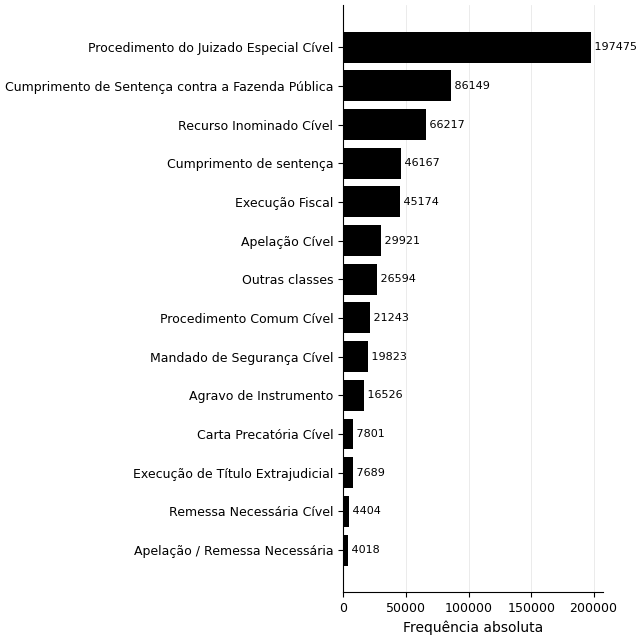

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

plt.style.use("/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/apa.mplstyle")

# --- Gráfico de barras horizontais (exclui a linha "Total", mantém "Outras classes") ---
dados_grafico = tabela_final[tabela_final["Classe"] != "Total"].copy()
dados_grafico = dados_grafico.sort_values("Frequência Absoluta", ascending=True)  # menor embaixo, maior no topo

fig, ax = plt.subplots(figsize=(6.5, 0.4 * len(dados_grafico) + 1))
ax.barh(dados_grafico["Classe"], dados_grafico["Frequência Absoluta"], color="black")

ax.set_xlabel("Frequência absoluta")
ax.set_ylabel("")
ax.grid(axis="x")  # horizontal vira vertical no barh
ax.grid(axis="y", visible=False)

for i, v in enumerate(dados_grafico["Frequência Absoluta"]):
    ax.text(v, i, f" {v}", va="center", fontsize=8)

fig.tight_layout()
fig.savefig("figura_classes_processuais.png", dpi=300)
plt.show()

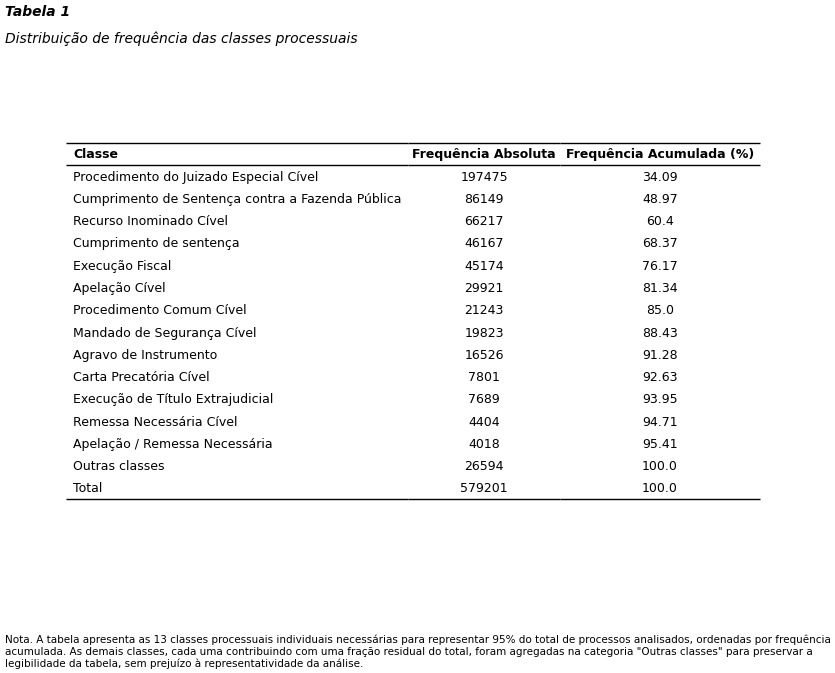

In [28]:
tabela_final = tabela_final.copy()
tabela_final["Frequência Acumulada (%)"] = tabela_final["Frequência Acumulada (%)"].round(2)

n_classes = len(tabela_final) - 2

fig, ax = plt.subplots(figsize=(8.5, 0.35 * len(tabela_final) + 1.4))
ax.axis("off")

tabela_apa = ax.table(
    cellText=tabela_final.values,
    colLabels=tabela_final.columns,
    cellLoc="center",
    loc="center"
)

tabela_apa.auto_set_font_size(False)
tabela_apa.set_fontsize(9)
tabela_apa.scale(1, 1.4)
tabela_apa.auto_set_column_width(col=list(range(len(tabela_final.columns))))

for (row, col), cell in tabela_apa.get_celld().items():
    cell.set_linewidth(0)
    cell.PAD = 0.03

    if col == 0:  # coluna "Classe": alinhada à esquerda
        cell.get_text().set_ha("left")
        cell.set_text_props(ha="left")
        cell.PAD = 0.02

    if row == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "TB"
        cell.set_linewidth(1.0)
        if col == 0:
            cell.get_text().set_ha("left")
    elif row == len(tabela_final):
        cell.visible_edges = "B"
        cell.set_linewidth(1.0)
    else:
        cell.visible_edges = ""

fig.text(0.02, 0.97, "Tabela 1", fontsize=10, fontweight="bold", fontstyle="italic")
fig.text(0.02, 0.93, "Distribuição de frequência das classes processuais", fontsize=10, fontstyle="italic")

nota = (
    f"Nota. A tabela apresenta as {n_classes} classes processuais individuais necessárias "
    "para representar 95% do total de processos analisados, ordenadas por frequência "
    "acumulada. As demais classes, cada uma contribuindo com uma fração residual do total, "
    "foram agregadas na categoria \"Outras classes\" para preservar a legibilidade da tabela, "
    "sem prejuízo à representatividade da análise."
)
fig.text(0.02, 0.04, nota, fontsize=7.5, wrap=True, ha="left", va="top")

fig.tight_layout(rect=[0, 0.12, 1, 0.90])
fig.savefig("tabela1_classes_processuais.png", dpi=300)
plt.show()

In [26]:
fig.savefig("/content/drive/MyDrive/Main/Cursos/ISCTE/MScBA/Dissertação/Code/Dataset/Colab/figura_classes_processuais.png", dpi=300)

In [29]:
# 1. Lista das 13 classes mantidas (exclui "Outras classes" e "Total")
classes_mantidas = tabela_final.loc[
    ~tabela_final["Classe"].isin(["Outras classes", "Total"]), "Classe"
].tolist()

print(f"Classes mantidas ({len(classes_mantidas)}): {classes_mantidas}")

# 2. IDs dos processos que pertencem a essas classes
ids_validos = processos_com_classe.loc[
    processos_com_classe["classe"].isin(classes_mantidas), "id"
]

print(f"Processos antes do saneamento: {processos_com_classe['id'].nunique()}")
print(f"Processos após o saneamento: {ids_validos.nunique()}")

# 3. Aplicar o filtro a cada DataFrame que tem o id do processo como chave
processos = processos[processos["id"].isin(ids_validos)].reset_index(drop=True)
classes = classes[classes["processo_id"].isin(ids_validos)].reset_index(drop=True)
processos_com_classe = processos_com_classe[
    processos_com_classe["id"].isin(ids_validos)
].reset_index(drop=True)

print(f"processos: {len(processos)} linhas")
print(f"classes: {len(classes)} linhas")
print(f"processos_com_classe: {len(processos_com_classe)} linhas")

Classes mantidas (13): ['Procedimento do Juizado Especial Cível', 'Cumprimento de Sentença contra a Fazenda Pública', 'Recurso Inominado Cível', 'Cumprimento de sentença', 'Execução Fiscal', 'Apelação Cível', 'Procedimento Comum Cível', 'Mandado de Segurança Cível', 'Agravo de Instrumento', 'Carta Precatória Cível', 'Execução de Título Extrajudicial', 'Remessa Necessária Cível', 'Apelação / Remessa Necessária']
Processos antes do saneamento: 579201
Processos após o saneamento: 552607
processos: 552607 linhas
classes: 552607 linhas
processos_com_classe: 552607 linhas


In [ ]:
movimentos = movimentos[movimentos["processo_id"].isin(ids_validos)].reset_index(drop=True)
movimentos_complementos = movimentos_complementos[
    movimentos_complementos["processo_id"].isin(ids_validos)
].reset_index(drop=True)


In [4]:
processos_com_classe.head()

NameError: name 'processos_com_classe' is not defined

In [9]:
# 1. Extrair a lista de nomes das classes válidas (aqueles 95%)
classes_validas = tabela_final["Classe"].tolist()

# 2. Descobrir dinamicamente o nome da primeira coluna da tabela 'classes' e buscar os IDs
coluna_id_classes = classes.columns[0]
ids_validos = classes[classes["nome"].isin(classes_validas)][coluna_id_classes].unique()

# 3. Filtrar todos os dataframes usando a primeira coluna (índice 0) de cada um deles
processos = processos[processos[processos.columns[0]].isin(ids_validos)]
orgaos_julgadores = orgaos_julgadores[orgaos_julgadores[orgaos_julgadores.columns[0]].isin(ids_validos)]
classes = classes[classes[classes.columns[0]].isin(ids_validos)]
sistemas = sistemas[sistemas[sistemas.columns[0]].isin(ids_validos)]
formatos = formatos[formatos[formatos.columns[0]].isin(ids_validos)]
assuntos = assuntos[assuntos[assuntos.columns[0]].isin(ids_validos)]
movimentos = movimentos[movimentos[movimentos.columns[0]].isin(ids_validos)]
movimentos_complementos = movimentos_complementos[movimentos_complementos[movimentos_complementos.columns[0]].isin(ids_validos)]

print("Filtro aplicado com sucesso!")
print(f"Linhas restantes em processos: {len(processos)}")
print(f"Linhas restantes em movimentos: {len(movimentos)}")

Filtro aplicado com sucesso!
Linhas restantes em processos: 528695
Linhas restantes em movimentos: 0


In [12]:
movimentos

,movimento_id,processo_id,movimento_codigo,movimento_nome,dataHora,movimento_orgaoJulgador_codigo,movimento_orgaoJulgador_nome
